Vamos a hacer un auto encoder el cual será capaz de eliminar el ruido de la señal entrante.
Primero cogemos todos los datos del cuaderno anterior

Database already exists, skipping download.
Let's see the value of the leads of the patient 100:  
 [[-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 ...
 [-0.675 -0.365]
 [-0.765 -0.335]
 [-1.28   0.   ]]
We can now separate the values of each channel:
The leads were:  ['MLII', 'V5'] 
 Channel 1:  [-0.145 -0.065 -0.145 ... -0.19  -0.355 -0.205] 
 Channel 2:  [-0.355 -0.225 -0.36  ... -0.335 -1.28   0.   ]
Data already exists, loading from disk...
Count of each symbol:  
 Counter({'N': 75052, 'L': 8075, 'R': 7259, 'V': 7130, '/': 7028, 'A': 2546, '+': 1291, 'f': 982, 'F': 803, '~': 616, '!': 472, '"': 437, 'j': 229, 'x': 193, 'a': 150, '|': 132, 'E': 106, 'J': 83, 'Q': 33, 'e': 16, '[': 6, ']': 6, 'S': 2})
We are going to filter the most relevant symbols of each aami class(N, S, V, F, Q).


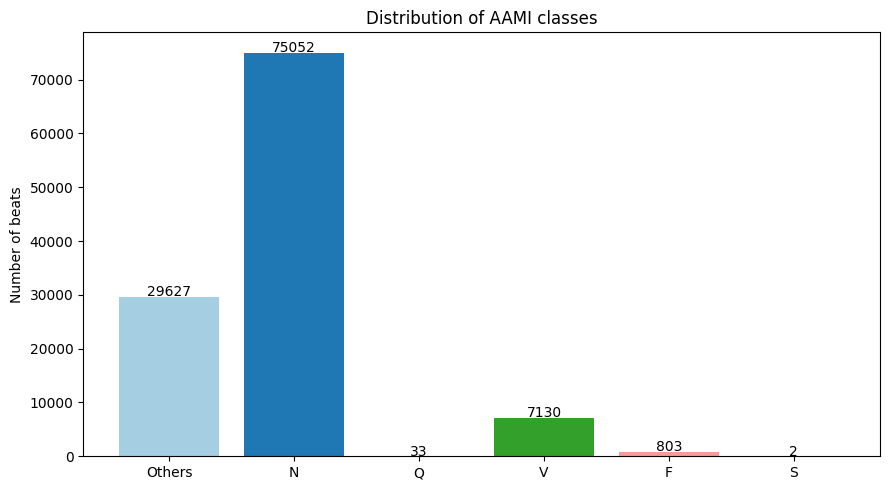

In [1]:
from ipynb.fs.full.pre_process_final import *

Vamos a graficar un ejemplo de latido de un paciente

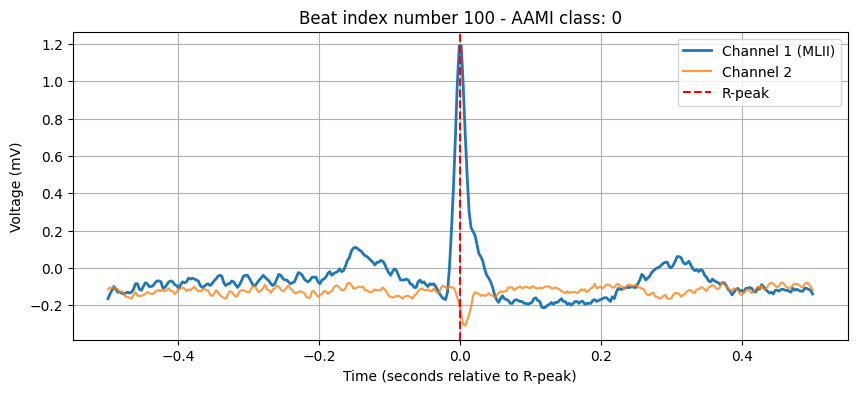

In [2]:
beat_index = 100
beats_extraction = X_train[beat_index]
beats_label = y_train[beat_index]

time = np.linspace(-0.5, 0.5, 360)

plt.figure(figsize=(10, 4))
plt.plot(time, beats_extraction[:, 0], label='Channel 1 (MLII)', color='#1f77b4', linewidth=2)
plt.plot(time, beats_extraction[:, 1], label='Channel 2', color='#ff7f0e', alpha=0.8)
plt.axvline(x=0, color='red', linestyle='--', label='R-peak')

plt.title(f'Beat index number {beat_index} - AAMI class: {beats_label}')
plt.xlabel('Time (seconds relative to R-peak)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.grid(True)
plt.show()

Ahora metemos ruido gaussiano síntetico para simular el peor caso en el que exista de verdad. Así nuestro encoder aprende a hacer denoising 

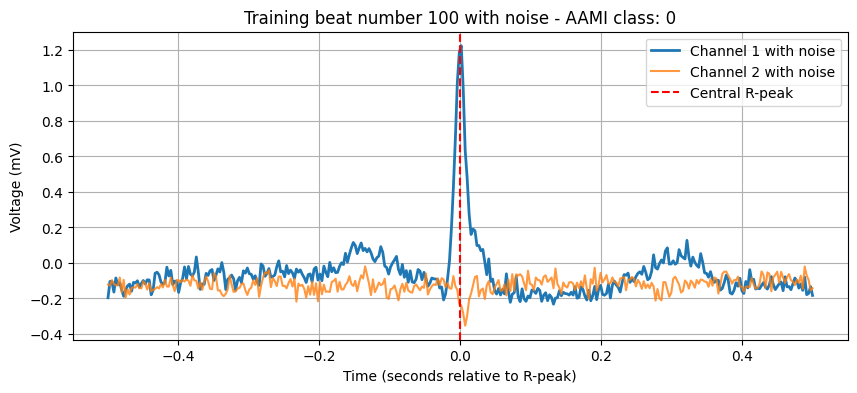

In [3]:
mean = 0
std = 0.03
X_train_noisy = X_train + np.random.normal(mean, std, X_train.shape) 
X_test_noisy = X_test + np.random.normal(mean, std, X_test.shape) 

plt.figure(figsize = (10, 4))
plt.plot(time, X_train_noisy[beat_index][:, 0], label='Channel 1 with noise', color='#1f77b4', linewidth=2)
plt.plot(time, X_train_noisy[beat_index][:, 1], label='Channel 2 with noise', color='#ff7f0e', alpha=0.8)
plt.axvline(x=0, color='red', linestyle='--', label='Central R-peak')
plt.title(f'Training beat number {beat_index} with noise - AAMI class: {beats_label}')
plt.xlabel('Time (seconds relative to R-peak)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.grid(True)
plt.show()

Construimos nuestro modelo, vamos a usar LSTM bi-lateral a que aprenderá del futuro y del pasado lo que será útil

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, RepeatVector, TimeDistributed, UpSampling1D, Conv1DTranspose, Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

def normalize(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1,  keepdims=True) + 1e-8
    return (X - mean) / std, mean, std  # devolvemos también mean y std

#Normalizamos valores
X_train_norm, mean_tr, std_tr = normalize(X_train)
X_train_noisy_norm = (X_train_noisy - mean_tr) / std_tr  

X_test_norm, mean_te, std_te = normalize(X_test)
X_test_noisy_norm = (X_test_noisy - mean_te) / std_te  

def wmse(y_true, y_pred):
    '''
    Definimos la función weighted mse ya que va a ser más útil debido a la gran cantidad de datos con latidos normales
    '''
    error = tf.square(y_true - y_pred)
    weights = tf.abs(y_true) + 1.0 
    
    return tf.reduce_mean(error * weights)

model = Sequential()

model.add(Input(shape=(360, 2)))
model.add(Conv1D(filters=32, kernel_size=11, padding='same', activation='relu'))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Bidirectional(LSTM(32, return_sequences=True)))
model.add(TimeDistributed(Dense(32, activation='relu')))
model.add(TimeDistributed(Dense(2, activation='linear'))) 

model.compile(optimizer=Adam(learning_rate=0.0005), loss=wmse)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 360, 32)        │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 360, 128)       │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 360, 64)        │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 360, 32)        │         2,080 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 360, 2)         │            66 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,762 (366.26 KB)

 Trainable params: 93,762 (366.26 KB)

 Non-trainable params: 0 (0.00 B)

ya tenemos nuestro modelo formado por una CNN+Bi-LSTM. Ahora encajas el modelo y entrenamos

In [5]:
early_stopping = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

TRAIN_MODEL = False # Cambiar a True si queremos re-entrenar el modelo

if TRAIN_MODEL:
    print("Training the model...")
    model.fit(
        X_train_noisy_norm,   
        X_train_norm,       
        epochs=50, 
        batch_size=64, 
        callbacks=[early_stopping], 
        validation_data=(X_test_noisy_norm, X_test_norm)  
    )

    model.save("autoencoder.keras") 
    print("Model saved")

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


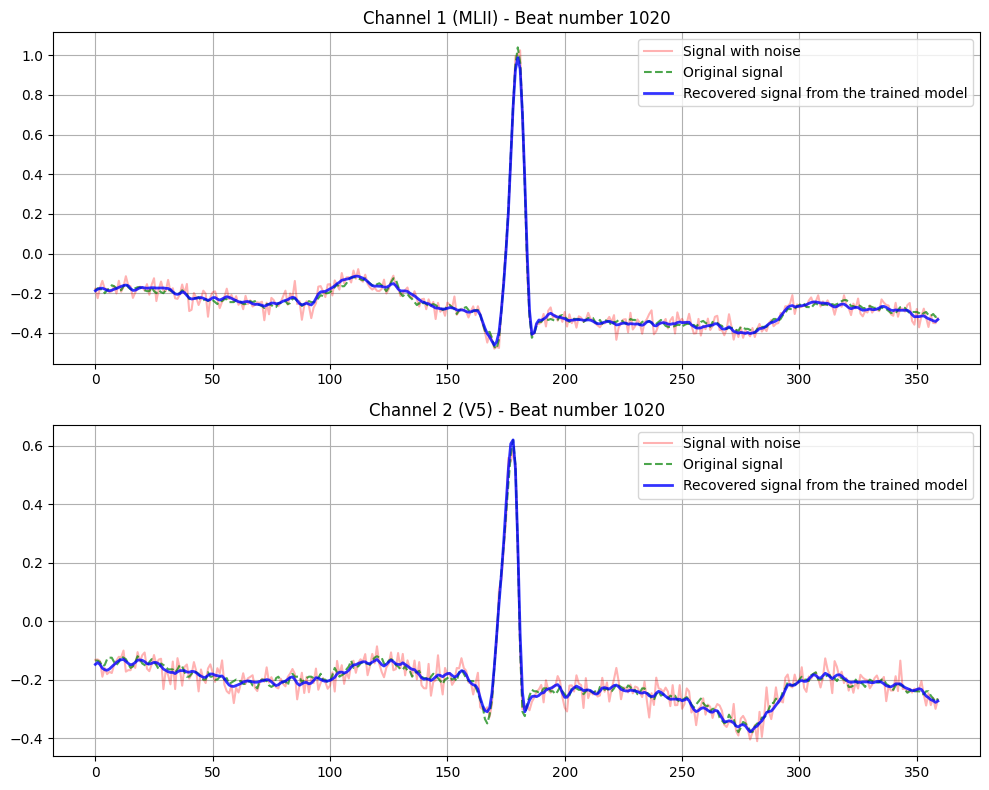

In [6]:
from tensorflow.keras.models import load_model

index = 1020
model = load_model("autoencoder.keras", compile=False)

# Guardamos mean y std del latido original (sin ruido) para desnormalizar
mean_i = X_test[index].mean(axis=0, keepdims=True)  
std_i  = X_test[index].std(axis=0,  keepdims=True) + 1e-8

# Normalizamos el latido sucio con esos mismos parámetros
latido_sucio_norm = (X_test_noisy[index:index+1] - mean_i) / std_i

# Predecimos en espacio normalizado
latido_limpio_norm = model.predict(latido_sucio_norm)

# Desnormalizamos
latido_limpio = latido_limpio_norm[0] * std_i + mean_i

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Canal 1 
ax1.plot(X_test_noisy[index][:, 0], color='red',   alpha=0.3,      label='Signal with noise')
ax1.plot(X_test[index][:, 0],       color='green', linestyle='--', label='Original signal', alpha=0.7)
ax1.plot(latido_limpio[:, 0],       color='blue',  linewidth=2,    label='Recovered signal from the trained model', alpha=0.8)
ax1.set_title(f'Channel 1 (MLII) - Beat number {index}')
ax1.legend()
ax1.grid(True)

# Canal 2 
ax2.plot(X_test_noisy[index][:, 1], color='red',   alpha=0.3,      label='Signal with noise')
ax2.plot(X_test[index][:, 1],       color='green', linestyle='--', label='Original signal', alpha=0.7)
ax2.plot(latido_limpio[:, 1],        color='blue',  linewidth=2,    label='Recovered signal from the trained model', alpha=0.8)
ax2.set_title(f'Channel 2 (V5) - Beat number {index}')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()